# Assignment: 16 Recommendation System

# Data Preprocessing:

Load the dataset into a suitable data structure (e.g., pandas DataFrame).

Handle missing values, if any.

Explore the dataset to understand its structure and attribut

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("anime.csv")
df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


In [29]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [31]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [32]:
df['genre'].fillna('Unknow', inplace=True)
df['type'].fillna('Unknow', inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_26348\3137594764.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['genre'].fillna('Unknow', inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_26348\3137594764.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [33]:
df['rating'].fillna(df['rating'].mean(), inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_26348\1561337004.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].mean(), inplace=True)


In [34]:
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [35]:
df['episoded'] = pd.to_numeric(df['episodes'], errors='coerce')

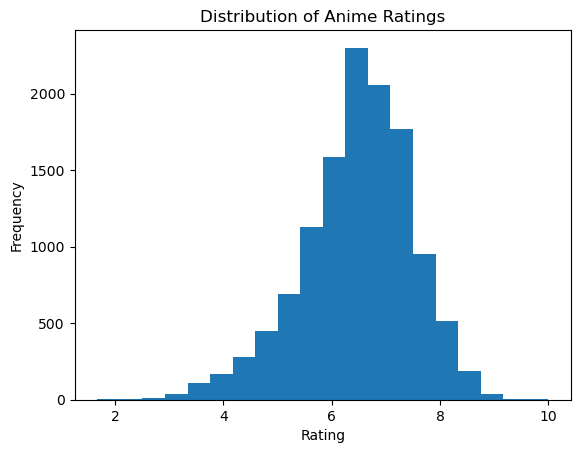

In [36]:
plt.figure()
plt.hist(df['rating'], bins=20)
plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

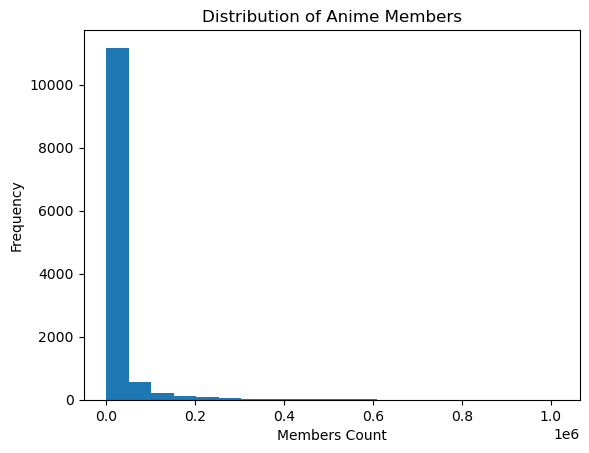

In [37]:
plt.figure()
plt.hist(df['members'], bins=20)
plt.title("Distribution of Anime Members")
plt.xlabel("Members Count")
plt.ylabel("Frequency")
plt.show()

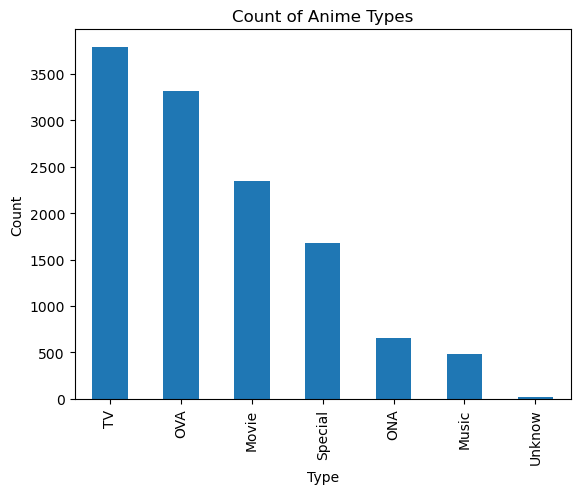

In [38]:
plt.figure()
df['type'].value_counts().plot(kind='bar')
plt.title("Count of Anime Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

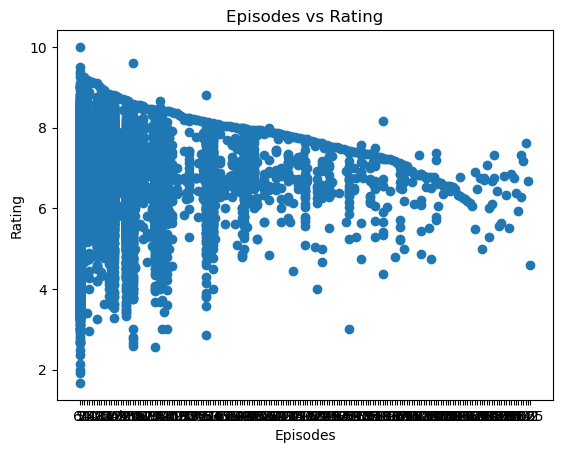

In [39]:
plt.figure()
plt.scatter(df['episodes'], df['rating'])
plt.title("Episodes vs Rating")
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.show()


# Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).

Convert categorical features into numerical representations if necessary.

Normalize numerical features if required.


In [40]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
col = df[['genre', 'type', 'rating', 'members']]

In [50]:
df_encoded = pd.get_dummies(df, columns=['genre', 'type'])

In [60]:
df_encoded['episodes'] = pd.to_numeric(df_encoded['episodes'], errors='coerce')
df_encoded['episodes'] = df_encoded['episodes'].fillna(0)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[['rating', 'members']] = scaler.fit_transform(df_encoded[['rating', 'members']])

In [59]:
final_features = df_encoded.drop(['anime_id', 'name','episodes'], axis=1)

In [53]:
final_features

,episodes,rating,members,episoded,genre_Action,"genre_Action, Adventure","genre_Action, Adventure, Cars, Comedy, Sci-Fi, Shounen","genre_Action, Adventure, Cars, Mecha, Sci-Fi, Shounen, Sports","genre_Action, Adventure, Cars, Sci-Fi","genre_Action, Adventure, Comedy",...,genre_Unknow,genre_Vampire,genre_Yaoi,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV,type_Unknow
0,1,2.847535,3.330241,1.0,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,64,2.739380,14.148406,64.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,51,2.729547,1.754713,51.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,24,2.650889,11.957666,24.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,51,2.641057,2.429742,51.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12289,1,-2.284933,-0.325809,1.0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
12290,1,-2.157113,-0.326320,1.0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
12291,4,-1.567174,-0.325663,4.0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
12292,1,-1.468851,-0.326466,1.0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [61]:
final_features.dtypes

rating                     float64
members                    float64
episoded                   float64
genre_Action                  bool
genre_Action, Adventure       bool
                            ...   
type_ONA                      bool
type_OVA                      bool
type_Special                  bool
type_TV                       bool
type_Unknow                   bool
Length: 3275, dtype: object

In [65]:
final_features = final_features.fillna(0)

# Recommendation System:

Design a function to recommend anime based on cosine similarity.

Given a target anime, recommend a list of similar anime based on cosine similarity scores.

Experiment with different threshold values for similarity scores to adjust the recommendation list size.

Analyze the performance of the recommendation system and identify areas of improvement.

In [66]:
from sklearn.metrics.pairwise import cosine_similarity

In [67]:
def recommend_anime(anime_name, df, col, top_n=5):
    if anime_name not in df['name'].values:
        return "Anime not found in dataset"
    
    idx = df[df['name'] == anime_name].index[0]
    similarity = cosine_similarity(col)
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    top_indices = [i[0] for i in scores[1:top_n+1]]
    return df.iloc[top_indices]['name']

In [68]:
recommend_anime("Naruto", df, final_features)

288                 Fairy Tail
6       Hunter x Hunter (2011)
304                 D.Gray-man
4444            Dragon Ball GT
255          Fairy Tail (2014)
Name: name, dtype: object

In [69]:
# similarity thersholds

def recommend_with_threshold(anime_name, df, col, threshold=0.7):
    idx = df[df['name'] == anime_name].index[0]
    similarity = cosine_similarity(col)
    
    similar_indices = [
        i for i, score in enumerate(similarity[idx])
        if score >= threshold and i != idx
    ]
    
    return df.iloc[similar_indices]['name']

In [70]:
# Different Thersholds
recommend_with_threshold("Naruto", df, final_features, threshold=0.8)
recommend_with_threshold("Naruto", df, final_features, threshold=0.6)

1                         Fullmetal Alchemist: Brotherhood
2                                                 Gintama°
3                                              Steins;Gate
4                                            Gintama&#039;
5        Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...
                               ...                        
12277                     Original Video Romance Animation
12281                                       Sakura no Mori
12284                                   Super Erotic Anime
12286                                  Teleclub no Himitsu
12291                       Violence Gekiga David no Hoshi
Name: name, Length: 6258, dtype: object

| Threshold | Recommendation Size      |
| --------- | ------------------------ |
| 0.8       | Very few, highly similar |
| 0.6       | Balanced recommendations |
| 0.4       | Many, but less accurate  |


Performance Analysis:

- Simple and explainable

- No training required

- Fast for medium-sized datasets

- Works well for content-based similarity

Areas of Improvement

- Use TF-IDF for genres instead of one-hot encoding

- Add user ratings for collaborative filtering

- Apply dimensionality reduction (PCA)

Summary:

- Cosine similarity was used to measure similarity between anime feature vectors

- Similar anime were recommended based on similarity scores

- Threshold values controlled recommendation list size

- System performance can be improved using advanced feature engineering

# Interview Questions:

# 1) Can you explain the difference between user-based and item-based collaborative filtering?

Ans:User-based filtering focuses on similar users, while item-based filtering focuses on similar items.

Example:

If users A and B like the same anime, recommend anime liked by A to B

If a user liked Naruto, recommend anime similar to Naruto

# 2) What is collaborative filtering, and how does it work?

Ans:

Collaborative filtering recommends items based on user interaction patterns.
It works by finding similarities between users or items and suggesting items with similar preferences.

Example: 
Netfilx recommending movies, Amazon suggesting products

How It Works (Step-by-Step): 

- Collect user-item interaction data (ratings, likes, views)

- Identify patterns in user behavior

- Find similarities using methods like cosine similarity

- Recommend items based on similar users or items
